<a href="https://colab.research.google.com/github/pakawatbmmd/Classroom-example/blob/main/lab01_nocode_ai_and_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wdittaya/AI-for-digital-health-course/blob/main/lab01_nocode_ai_and_data_exploration.ipynb)

# Lab 1: ปัญญาประดิษฐ์แบบไม่ต้องเขียนโปรแกรม (No-Code AI) และการสำรวจข้อมูลสุขภาพ

**รายวิชา:** 3099704 AI for Digital Health (2026) · **คาบเรียน:** วันพฤหัสบดีที่ 1 ตุลาคม 2026 · **เวลาโดยประมาณ:** 60–90 นาที

## วัตถุประสงค์การเรียนรู้

- เข้าใจระดับของการพัฒนาปัญญาประดิษฐ์ (AI) ตั้งแต่แบบไม่ต้องเขียนโปรแกรม (no-code) แบบเขียนโปรแกรมเพียงเล็กน้อย (low-code) จนถึงแบบเขียนโปรแกรมเต็มรูปแบบ (code)
- ฝึกสอนโมเดลจำแนกภาพ (image classifier) บนเว็บเบราว์เซอร์ด้วย Teachable Machine โดยไม่ต้องเขียนโปรแกรม
- สำรวจและทำความสะอาดชุดข้อมูล (dataset) สุขภาพจริงด้วย pandas
- จัดทำรายงานสรุปลักษณะชุดข้อมูล (data profiling report) ฉบับย่อ

> **แนวทางการทำปฏิบัติการ** (งานเดี่ยว)
>
> ✅ **ส่วนหลัก — สำหรับผู้เรียนทุกคน ไม่จำเป็นต้องมีพื้นฐานการเขียนโปรแกรม** ส่วน A ดำเนินการบนเว็บเบราว์เซอร์ สำหรับส่วน B ให้รันเซลล์ (cell) ตามลำดับจากบนลงล่าง (คลิกปุ่ม ▶ ทางซ้ายของเซลล์ หรือกด **Shift+Enter**) เซลล์ ⭐ **แบบฝึกหัด (Exercise)** แต่ละเซลล์มีเซลล์ ✅ **เฉลย** อยู่ถัดไป ให้ทดลองทำแบบฝึกหัดด้วยตนเองก่อน หากไม่สามารถดำเนินการต่อได้ ให้รันเซลล์เฉลยแล้วทำขั้นตอนถัดไป จากนั้นให้ตอบคำถาม ✍️ ในเซลล์ข้อความ (ดับเบิลคลิกที่เซลล์ `✍️ คำตอบ:` เพื่อพิมพ์) **คำตอบดังกล่าวคือชิ้นงานที่ต้องส่ง**
>
> 🏆 **โจทย์ท้าทายบนตารางอันดับ — ไม่บังคับ สำหรับผู้เรียนที่เขียนโปรแกรมได้** ท้ายโน้ตบุ๊ก (notebook) มีโจทย์เสริมซึ่งให้คะแนนโดยอัตโนมัติบนตารางอันดับ ([Hugging Face leaderboard](https://huggingface.co/spaces/wdittaya/aidh-leaderboard)) ของรายวิชา โจทย์นี้ **ไม่เป็นส่วนหนึ่งของชิ้นงานที่ต้องส่ง** ผู้เรียนที่ประสงค์จะเข้าร่วมให้ระบุนามแฝงใน `NAME` และรหัสเข้าร่วมซึ่งผู้สอนประกาศในการเรียนการสอนผ่าน Zoom ใน `JOIN_CODE` ในเซลล์การตั้งค่าด้านล่าง
>
> ปฏิบัติการทั้งหมดรันได้บน [Google Colab](https://colab.research.google.com) รุ่นไม่มีค่าใช้จ่าย (ไม่ต้องใช้ GPU) หากพบปัญหา สามารถสอบถามผู้สอนผ่านช่องแชตของ Zoom

In [3]:
# @title ⚙️ การตั้งค่า — โปรดรันเซลล์นี้ก่อน (NAME และ JOIN_CODE ใช้เฉพาะโจทย์ท้าทายบนตารางอันดับ ซึ่งไม่บังคับ)
!pip -q install gradio_client huggingface_hub

HF_OWNER  = "wdittaya"     # บัญชี Hugging Face ที่ใช้โฮสต์ตารางอันดับของรายวิชา (ผู้สอนเป็นผู้กำหนด)
LAB_ID    = "lab01"
NAME      = ""            # ไม่บังคับ: ชื่อที่จะแสดงบนตารางอันดับแบบสาธารณะ (สามารถใช้นามแฝงได้)
JOIN_CODE = "3099704-dwn"            # ไม่บังคับ: รหัสเข้าร่วมซึ่งผู้สอนประกาศในการเรียนการสอนผ่าน Zoom

SPACE_ID  = f"{HF_OWNER}/aidh-leaderboard"
DATA_REPO = f"{HF_OWNER}/aidh-lab-data"

from huggingface_hub import hf_hub_download

def lab_data(path):
    """ดาวน์โหลดไฟล์ข้อมูลทดสอบสาธารณะของรายวิชา 1 ไฟล์ (เช่น 'pima/test_ids.csv') และคืนค่าตำแหน่งไฟล์ในเครื่อง"""
    return hf_hub_download(DATA_REPO, path, repo_type="dataset")

def submit_to_leaderboard(path, lab=LAB_ID):
    """ส่งไฟล์ผลการทำนายไปยังตารางอันดับของรายวิชา และแสดงคะแนนพร้อมอันดับ"""
    from gradio_client import Client, handle_file
    assert NAME and JOIN_CODE, "โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่าก่อน (จำเป็นเฉพาะการส่งผลไปยังตารางอันดับ)"
    client = Client(SPACE_ID, verbose=False)
    print(client.predict(lab=lab, name=NAME, code=JOIN_CODE, file=handle_file(path), api_name="/submit"))

print(f"Leaderboard: https://huggingface.co/spaces/{SPACE_ID}  |  lab={LAB_ID}  name={NAME or '(ยังไม่ได้ระบุ — ตารางอันดับไม่บังคับ)'}")

Leaderboard: https://huggingface.co/spaces/wdittaya/aidh-leaderboard  |  lab=lab01  name=(ยังไม่ได้ระบุ — ตารางอันดับไม่บังคับ)


## ส่วน A — ปัญญาประดิษฐ์แบบไม่ต้องเขียนโปรแกรม: Teachable Machine (~30 นาที)

ส่วนนี้ไม่ต้องเขียนโปรแกรม ขั้นตอนทั้งหมดดำเนินการบนเว็บเบราว์เซอร์

1. เปิด [Teachable Machine](https://teachablemachine.withgoogle.com/) → **Get Started → Image Project → Standard image model**
2. สร้างคลาส (class) 2–3 คลาส โดยเปลี่ยนชื่อ "Class 1", "Class 2", … เช่น *แบมือ*, *กำมือ*, *ไม่มีมือ* แล้วเพิ่มภาพด้วย **Webcam** (กดปุ่มค้างไว้เพื่อบันทึกภาพต่อเนื่อง) หรือ **Upload** (หากไม่มีกล้องเว็บแคม สามารถใช้ภาพจากโทรศัพท์หรือคอมพิวเตอร์ได้)
   สำหรับโจทย์ทางการแพทย์ (ไม่บังคับ): ดาวน์โหลดภาพรอยโรคผิวหนังสาธารณะจาก [ISIC Archive](https://gallery.isic-archive.com/) เพื่อสร้างคลาส *benign (ไม่ร้ายแรง) และ malignant (มะเร็ง)*
3. คลิก **Train Model** แล้วทดสอบในแผง **Preview** ด้วยภาพ *ใหม่* ที่โมเดลไม่เคยใช้ฝึก พร้อมบันทึกข้อสังเกต ดังนี้
   - เริ่มจากภาพจำนวนน้อย (ประมาณ 5 ภาพต่อคลาส) และตรวจสอบว่าโมเดลทำงานได้หรือไม่ จากนั้นเพิ่มภาพและฝึกใหม่
   - ทดสอบโดยเปลี่ยนฉากหลังหรือแสง (เช่น เปิดหรือปิดไฟ หรือเปลี่ยนตำแหน่ง)
4. คลิก **Export Model** เพื่อพิจารณาว่าโมเดลที่ฝึกแล้วสามารถนำไปใช้ในเว็บไซต์หรือแอปพลิเคชันได้อย่างไร ขั้นตอนนี้คือ "การนำไปใช้งานจริง (deployment)" (ไม่จำเป็นต้องดาวน์โหลดไฟล์ใด)

> 💡 **คำศัพท์สำคัญของรายวิชา:** *คลาส (class)* คือหมวดหมู่ที่โมเดลต้องเลือก; *การฝึกสอน (training)* คือกระบวนการที่โมเดลเรียนรู้รูปแบบจากตัวอย่าง; *การเปลี่ยนแปลงของการกระจายข้อมูล (distribution shift)* คือสภาวะที่ข้อมูลใหม่มีลักษณะแตกต่างจากข้อมูลที่ใช้ฝึก (เช่น สภาพแสงต่างกัน เครื่องสแกนของโรงพยาบาลอื่น หรือกลุ่มผู้ป่วยต่างกลุ่ม) ซึ่งเป็นปัญหาสำคัญที่สุดประการหนึ่งของปัญญาประดิษฐ์ทางการแพทย์

> 💡 ในการเรียนการสอนผ่าน Zoom ผู้สอนจะสาธิตแนวคิดเดียวกันด้วย [Vertex AI](https://cloud.google.com/vertex-ai) บน Google Cloud (ผู้เรียนไม่จำเป็นต้องมีบัญชีของตนเอง)

### ✍️ คำถาม — ส่วน A

**A1.** โปรดระบุคลาสที่ผู้เรียนสร้าง และจำนวนภาพต่อคลาสโดยประมาณที่จำเป็นก่อนที่โมเดลจะทำงานได้ในระดับที่ยอมรับได้

✍️ **คำตอบ:**

Diabetic Retinopathy vs No Diabetic Retinopathy
12 pictures each group with mix severeity degrees in DR group.

**A2.** จงอธิบายผลที่เกิดขึ้นเมื่อเปลี่ยนแสงหรือฉากหลัง (หรือเมื่อทดสอบด้วยภาพที่แตกต่างจากภาพที่ใช้ฝึก) และเชื่อมโยงกับ *distribution shift* ในบริบทของโรงพยาบาล (เช่น โมเดลที่ฝึกด้วยข้อมูลของโรงพยาบาลหนึ่งแล้วนำไปใช้ในอีกโรงพยาบาลหนึ่ง)

✍️ **คำตอบ:**

With different devices whether in type or how advance it is, will effect the quality, underlying pixel patterns, and characteristic of the images.

**A3.** โปรดยกตัวอย่างงาน 1 งานในหน่วยงานของผู้เรียนที่เครื่องมือแบบไม่ต้องเขียนโปรแกรมลักษณะนี้ *เพียงพอ* และ 1 งานที่ *ไม่เพียงพอ* พร้อมเหตุผล (โดยพิจารณาความปลอดภัยของผู้ป่วย ความเป็นส่วนตัวของข้อมูล การตรวจสอบความถูกต้อง (validation) และข้อกำหนดทางกฎหมาย)

✍️ **คำตอบ:**
No-code enough: medical documents classifications, for example convert papers document via OCR and sort them into specific catagories.
Low risk, if model is wrong, it will has not much effect on real clinical of patient, just let the staff re-sort the documents.

No-code not enough: sepsis prediction model, high risk, if miss diagnosis, this will directly effect the patient managment.

## ส่วน B — การเขียนโปรแกรม: การสำรวจชุดข้อมูลเบาหวาน Pima (~40 นาที)

ปฏิบัติการนี้ใช้ชุดข้อมูลสาธารณะ **Pima Indians Diabetes** ซึ่งประกอบด้วยข้อมูลของสตรีเชื้อสายชนพื้นเมืองอเมริกันเผ่า Pima อายุ 21 ปีขึ้นไป จำนวน 768 ราย จากการศึกษาของ US National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) โดย `Outcome` = 1 หมายถึงเป็นโรคเบาหวาน (ตามเกณฑ์ขององค์การอนามัยโลก (WHO)) และ 0 หมายถึงไม่เป็นโรคเบาหวาน

| คอลัมน์ | ความหมาย |
|---|---|
| `Pregnancies` | จำนวนครั้งของการตั้งครรภ์ |
| `Glucose` | ระดับน้ำตาลในพลาสมา (mg/dL) **ที่ 2 ชั่วโมงหลังดื่มกลูโคส 75 g ในการทดสอบความทนต่อกลูโคส (oral glucose tolerance test, OGTT)** — *ไม่ใช่* fasting glucose |
| `BloodPressure` | ความดันโลหิตขณะหัวใจคลายตัว (diastolic, mmHg) |
| `SkinThickness` | ความหนาของชั้นผิวหนังบริเวณกล้ามเนื้อไตรเซปส์ (triceps skin-fold, mm) |
| `Insulin` | ระดับอินซูลินในซีรัมที่ 2 ชั่วโมง (µU/mL) |
| `BMI` | ดัชนีมวลกาย (kg/m²) |
| `DiabetesPedigreeFunction` | คะแนนที่สะท้อนประวัติโรคเบาหวานในครอบครัว |
| `Age` | อายุ (ปี) |
| `Outcome` | 1 = เป็นโรคเบาหวาน, 0 = ไม่เป็นโรคเบาหวาน |

ส่วนนี้ใช้ **pandas** ซึ่งเป็นไลบรารีมาตรฐานของภาษา Python สำหรับจัดการข้อมูลตาราง (เทียบได้กับ Excel ในรูปแบบโปรแกรม) ตารางใน pandas เรียกว่า *DataFrame* และในปฏิบัติการนี้จัดเก็บไว้ในตัวแปร `df` ให้รันเซลล์ด้านล่างตามลำดับ

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(URL)
print(df.shape)   # (จำนวนแถว, จำนวนคอลัมน์) = (จำนวนผู้ป่วย, จำนวนตัวแปรที่วัด)
df.head()         # แสดงข้อมูลผู้ป่วย 5 รายแรก

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# คำสั่ง pandas พื้นฐาน 2 คำสั่งที่ใช้บ่อย
df.info()         # ชื่อคอลัมน์ ชนิดข้อมูล และจำนวนค่าที่ไม่ว่าง
df.describe()     # สถิติสรุปของแต่ละคอลัมน์: mean, std, min, ควอร์ไทล์, max

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


💡 **คำอธิบายผลลัพธ์** แต่ละแถวคือผู้ป่วย 1 ราย และแต่ละคอลัมน์คือตัวแปรที่วัด 1 ตัว คำสั่ง `describe()` แสดงจำนวน (count) ค่าเฉลี่ย (mean) ส่วนเบี่ยงเบนมาตรฐาน (standard deviation, *std*) ค่าต่ำสุด ควอร์ไทล์ (25%, 50% = มัธยฐาน (median), 75%) และค่าสูงสุดของทุกคอลัมน์

### ค่าสูญหายที่แฝงอยู่ (hidden missing values)

จากแถว `min` ข้างต้น ค่าต่ำสุดของ `Glucose`, `BloodPressure`, `BMI` … มีค่าเป็น **0** ซึ่งเป็นไปไม่ได้ทางสรีรวิทยา
ในข้อมูลทางคลินิกจริง ค่าสูญหาย (missing values) มักถูกบันทึกแฝงไว้ในรูปของเลข 0 หรือรหัสพิเศษ (เช่น 999) เซลล์ถัดไปจะแปลงเลข 0 ดังกล่าวให้เป็นค่าว่าง (`NaN` = *not a number*)

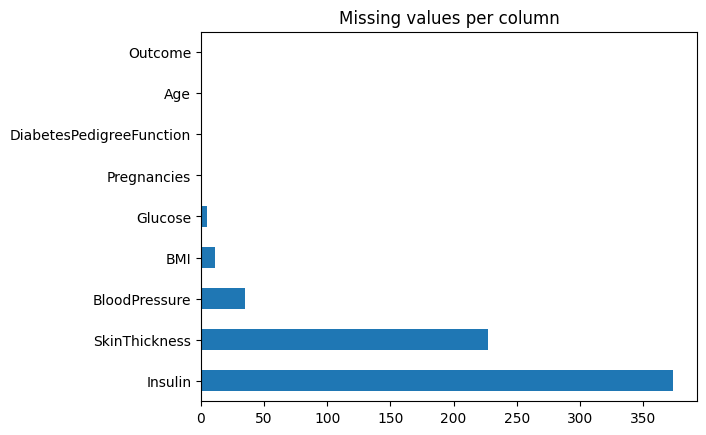

,0
Insulin,374
SkinThickness,227
BloodPressure,35
BMI,11
Glucose,5
Pregnancies,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
df_with_missing = df.copy()   # เก็บสำเนาที่ยังมีค่าว่าง สำหรับจัดทำรายงานสรุปข้อมูลในภายหลัง

missing = df.isnull().sum().sort_values(ascending=False)
missing.plot.barh(title="Missing values per column")
plt.show()
missing

**✍️ B1.** โปรดระบุคอลัมน์ที่มีค่าสูญหายแฝงอยู่มากที่สุด และเสนอเหตุผลทางคลินิก 1 ประการที่ทำให้ตัวแปรนี้มักไม่ได้รับการตรวจวัดหรือบันทึก

✍️ **คำตอบ:**
insulin, this is not a routine investigation for diagnosis DM.


### การแทนค่าสูญหาย (imputation)

การวิเคราะห์หลายวิธีไม่สามารถใช้ข้อมูลที่มีค่าว่างได้ วิธีแก้ไขเบื้องต้นคือการแทนค่าว่างด้วยค่าตัวแทนของคอลัมน์นั้น (*imputation*) ในที่นี้ใช้ **มัธยฐาน (median)** ซึ่งเป็นค่ากลางของข้อมูล เนื่องจากมัธยฐานไม่ได้รับผลกระทบจากค่าผิดปกติ (outlier) เพียงไม่กี่ค่า ต่างจากค่าเฉลี่ย

In [13]:
# ⭐ Exercise 1 — แบบฝึกหัดที่ 1: การแทนค่าสูญหายด้วยค่ามัธยฐาน
# วัตถุประสงค์: แทนค่าว่างทุกตำแหน่งในคอลัมน์ที่มีค่าสูญหาย ด้วยค่ามัธยฐาน (median) ของคอลัมน์นั้น
# สิ่งที่ต้องแก้ไข: แทน ... ด้วยค่ามัธยฐานของคอลัมน์
# คำใบ้: ค่ามัธยฐานของคอลัมน์เขียนได้เป็น  df_with_missing[col].median()
# (เซลล์นี้เริ่มจากสำเนา `df_with_missing` จึงสามารถรันซ้ำได้โดยไม่กระทบข้อมูล)

for col in zero_as_missing:
    df[col] = df_with_missing[col].fillna(df_with_missing[col].median())   # TODO

assert all(pd.api.types.is_numeric_dtype(df[c]) for c in zero_as_missing), "โปรดแทน ... ด้วย df_with_missing[col].median()"
assert df[zero_as_missing].isnull().sum().sum() == 0, "ยังมีค่าสูญหายเหลืออยู่"
print("✅ แทนค่าสูญหายครบถ้วนแล้ว")

✅ แทนค่าสูญหายครบถ้วนแล้ว


In [ ]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
for col in zero_as_missing:
    df[col] = df_with_missing[col].fillna(df_with_missing[col].median())

assert df[zero_as_missing].isnull().sum().sum() == 0, "ยังมีค่าสูญหายเหลืออยู่"
print("✅ แทนค่าสูญหายครบถ้วนแล้ว")

💡 **คำอธิบายผลลัพธ์** ค่าว่างทุกตำแหน่งถูกแทนด้วยค่ามัธยฐานของคอลัมน์ (เช่น 125 µU/mL สำหรับ `Insulin`) วิธีนี้ทำให้คงข้อมูลผู้ป่วยไว้ครบ 768 ราย แต่เท่ากับเป็นการ *สร้างข้อมูลขึ้นใหม่* กล่าวคือ ค่าอินซูลินเกือบครึ่งหนึ่งในขณะนี้เป็นค่าเดียวกันที่ถูกแทนเข้าไป

**✍️ B2.** หากนำข้อมูลนี้ไปฝึกโมเดลทำนายทางคลินิก การแทนค่า `Insulin` เกือบครึ่งหนึ่งด้วยค่ามัธยฐานเดียวกันมีความเสี่ยงอย่างไร โปรดระบุ 1 ประการ

✍️ **คำตอบ:**

Decrease variance and distribution.
Loss/dilute some correlation.
These might effect model performance and cause bias.

### การเปรียบเทียบผู้ป่วยที่เป็นและไม่เป็นโรคเบาหวาน

กราฟแต่ละรูปด้านล่างคือ *ฮิสโทแกรม (histogram)* ความสูงของแท่งแสดงจำนวนผู้ป่วยที่มีค่าอยู่ในช่วงนั้น สีน้ำเงิน = ไม่เป็นโรคเบาหวาน (Outcome 0) สีส้ม = เป็นโรคเบาหวาน (Outcome 1) ตัวแปรที่การกระจายของสองสีแยกจากกันชัดเจน คือตัวแปรที่ช่วยจำแนกสองกลุ่มได้ดี

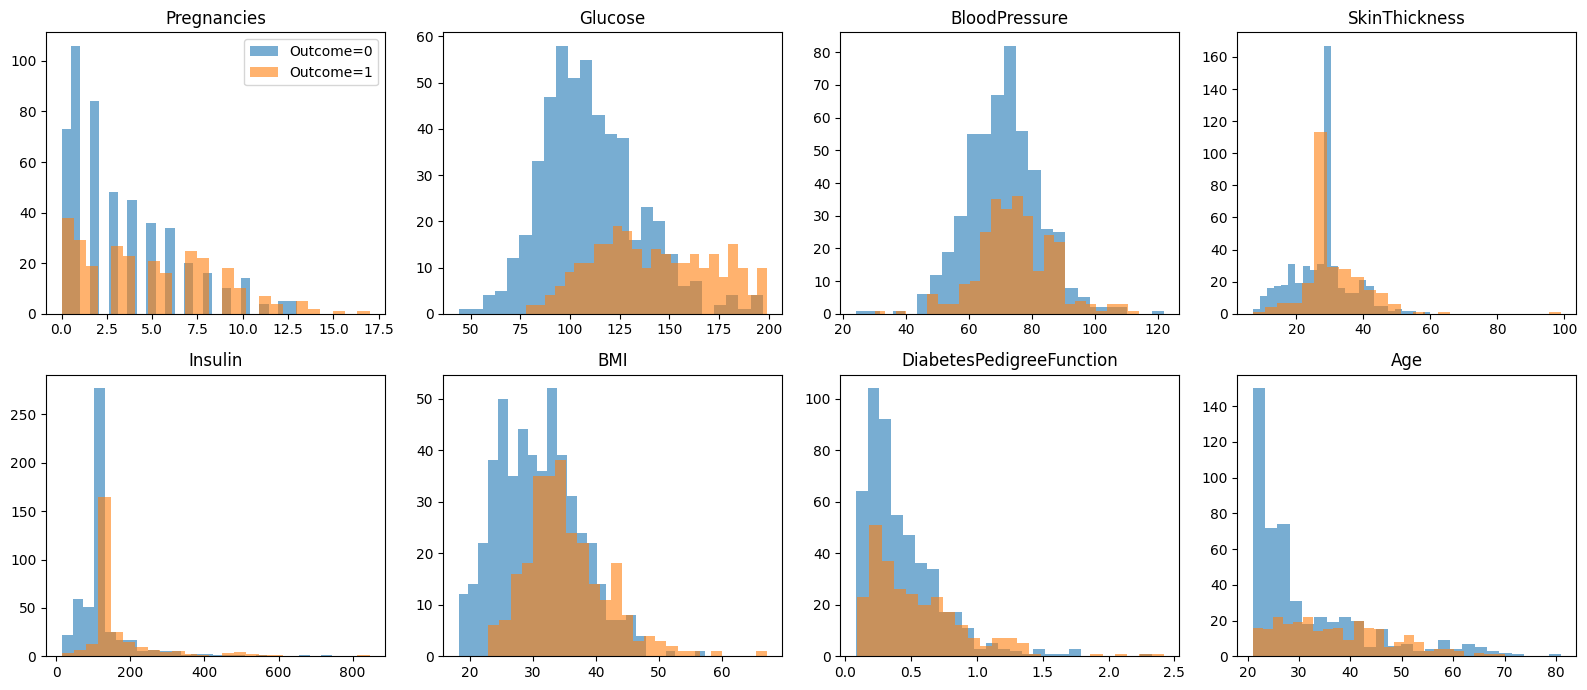

In [10]:
# การกระจายของแต่ละตัวแปร จำแนกตามผลลัพธ์ (0 = ไม่เป็นโรคเบาหวาน, 1 = เป็นโรคเบาหวาน)
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    for outcome, grp in df.groupby("Outcome"):
        ax.hist(grp[col], alpha=0.6, bins=25, label=f"Outcome={outcome}")
    ax.set_title(col)
axes.flat[0].legend()
plt.tight_layout()
plt.show()

💡 **คำอธิบายผลลัพธ์** แท่งที่สูงผิดปกติใน `Insulin` และ `SkinThickness` คือค่ามัธยฐานที่เพิ่งแทนเข้าไป ซึ่งเป็นผลข้างเคียงจากการแทนค่า (imputation artefact)

*แผนภาพความร้อนแสดงสหสัมพันธ์ (correlation heatmap)* ด้านล่างแสดงระดับความสัมพันธ์ระหว่างสองคอลัมน์: +1 = สัมพันธ์กันในทิศทางเดียวกันอย่างสมบูรณ์, 0 = ไม่สัมพันธ์กัน, −1 = สัมพันธ์กันในทิศทางตรงข้าม ให้พิจารณาที่แถว `Outcome`

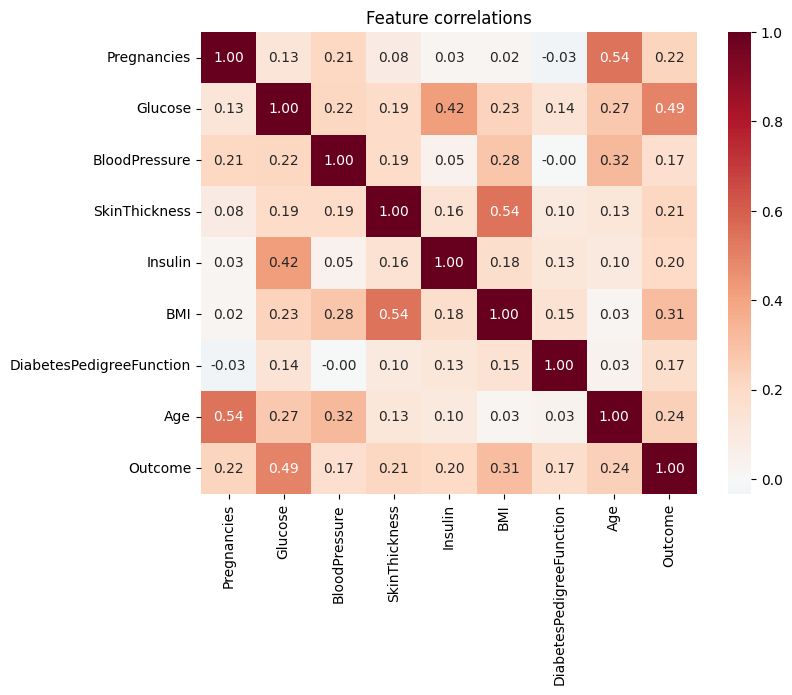

In [11]:
# แผนภาพความร้อนแสดงสหสัมพันธ์ (correlation heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Feature correlations")
plt.show()

### สถิติจำแนกตามกลุ่ม (group statistics)

คำสั่ง `groupby` แบ่งผู้ป่วยออกเป็นกลุ่ม (เช่น ตาม `Outcome`) แล้วคำนวณค่าสถิติของแต่ละกลุ่ม ในลักษณะเดียวกับ pivot table ใน Excel

In [14]:
# ⭐ Exercise 2 — แบบฝึกหัดที่ 2: สถิติจำแนกตามกลุ่ม
# วัตถุประสงค์: เปรียบเทียบผู้ป่วยที่เป็นและไม่เป็นโรคเบาหวาน และหาอัตราการเป็นโรคเบาหวานตามกลุ่มอายุ
# สิ่งที่ต้องแก้ไข: เติม ... ทั้ง 3 ตำแหน่ง (ตำแหน่งละ 1 คำหรือ 1 รายการ)
#  a) ค่าสถิติที่ต้องการคำนวณ                   → คำใบ้: "mean"
#  b) จุดแบ่งช่วงอายุ 0, 30, 50 และ 120          → คำใบ้: [0, 30, 50, 120]
#  c) คอลัมน์ที่ค่าเฉลี่ยเท่ากับอัตราการเป็นโรคเบาหวาน
#     (Outcome มีค่า 0/1 ค่าเฉลี่ยจึงเท่ากับสัดส่วนผู้ที่เป็นโรคเบาหวาน)   → คำใบ้: "Outcome"

group_stats = df.groupby("Outcome")[["Glucose", "BMI"]].agg("mean")                  # TODO (a)
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 30, 50, 120], labels=["<30", "30-50", ">50"])      # TODO (b)
rate_by_age = df.groupby("AgeGroup", observed=True)["Outcome"].mean()                   # TODO (c)

print(group_stats)
print(rate_by_age)

            Glucose        BMI
Outcome                       
0        110.682000  30.885600
1        142.130597  35.383582
AgeGroup
<30      0.215827
30-50    0.518519
>50      0.469136
Name: Outcome, dtype: float64


In [15]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
group_stats = df.groupby("Outcome")[["Glucose", "BMI"]].agg("mean")
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 30, 50, 120], labels=["<30", "30-50", ">50"])
rate_by_age = df.groupby("AgeGroup", observed=True)["Outcome"].mean()

print(group_stats)
print(rate_by_age)

            Glucose        BMI
Outcome                       
0        110.682000  30.885600
1        142.130597  35.383582
AgeGroup
<30      0.215827
30-50    0.518519
>50      0.469136
Name: Outcome, dtype: float64


💡 **คำอธิบายผลลัพธ์** `group_stats` แสดงค่าเฉลี่ยของระดับน้ำตาลที่ 2 ชั่วโมงและ BMI ในแต่ละกลุ่มผลลัพธ์ ส่วน `rate_by_age` แสดงสัดส่วนของสตรีที่เป็นโรคเบาหวานในแต่ละกลุ่มอายุ (0.20 = ร้อยละ 20) (กลุ่มอายุ: "<30" = ไม่เกิน 30 ปี, "30-50" = 31–50 ปี, ">50" = มากกว่า 50 ปี)

**✍️ B3.** จากฮิสโทแกรม แผนภาพความร้อน และสถิติจำแนกตามกลุ่ม ผู้เรียนพิจารณาว่าตัวแปรใดเพียงตัวเดียวที่จำแนกผู้ป่วยที่เป็นและไม่เป็นโรคเบาหวานได้ดีที่สุด เพราะเหตุใด และอัตราการเป็นโรคเบาหวานเปลี่ยนแปลงอย่างไรตามอายุ

✍️ **คำตอบ:**
Glucose, highest correlation.
DM is highest in age 30-50 years old.

### รายงานสรุปลักษณะข้อมูลฉบับย่อ (mini profiling report)

*Data profile* คือตารางที่สรุปลักษณะของทุกคอลัมน์ไว้ในตารางเดียว ซึ่งควรจัดทำเป็นขั้นตอนแรกเมื่อได้รับชุดข้อมูลทางคลินิกชุดใหม่ ในที่นี้จัดทำ profile จาก `df_with_missing` (ข้อมูล *ก่อน* การแทนค่า) เพื่อให้ยังคงเห็นค่าสูญหาย

In [16]:
# ⭐ Exercise 3 — แบบฝึกหัดที่ 3: รายงานสรุปลักษณะข้อมูลฉบับย่อ
# วัตถุประสงค์: สร้างตารางที่มี 1 แถวต่อ 1 คอลัมน์ ได้แก่ ชนิดข้อมูล จำนวนและร้อยละของค่าสูญหาย
#               จำนวนค่าที่ไม่ซ้ำกัน ค่าต่ำสุด และค่าสูงสุด
# สิ่งที่ต้องแก้ไข: เติม ... ทั้ง 2 ตำแหน่ง โดยใช้คำสั่ง pandas ต่อไปนี้
#     data[col].isnull().sum()   → นับจำนวนค่าสูญหายในคอลัมน์
#     data[col].nunique()        → นับจำนวนค่าที่ไม่ซ้ำกันในคอลัมน์

def profile(data):
    rows = []
    for col in data.columns:
        n_missing = ...                                  # TODO: จำนวนค่าสูญหาย
        rows.append({
            "column": col,
            "dtype": str(data[col].dtype),
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / len(data), 1),
            "n_unique": ...,                             # TODO: จำนวนค่าที่ไม่ซ้ำกัน
            "min": data[col].min() if pd.api.types.is_numeric_dtype(data[col]) else np.nan,
            "max": data[col].max() if pd.api.types.is_numeric_dtype(data[col]) else np.nan,
        })
    return pd.DataFrame(rows)

report = profile(df_with_missing)
report

,column,dtype,n_missing,pct_missing,n_unique,min,max
0,Pregnancies,int64,0,0.0,17,0.000,17.00
1,Glucose,float64,5,0.7,135,44.000,199.00
2,BloodPressure,float64,35,4.6,46,24.000,122.00
3,SkinThickness,float64,227,29.6,50,7.000,99.00
4,Insulin,float64,374,48.7,185,14.000,846.00
5,BMI,float64,11,1.4,247,18.200,67.10
6,DiabetesPedigreeFunction,float64,0,0.0,517,0.078,2.42
7,Age,int64,0,0.0,52,21.000,81.00
8,Outcome,int64,0,0.0,2,0.000,1.00


In [17]:
# @title ✅ เฉลย — หากไม่สามารถทำแบบฝึกหัดได้ ให้รันเซลล์นี้ (ดับเบิลคลิกเพื่อแสดงโค้ด) { display-mode: "form" }
def profile(data):
    rows = []
    for col in data.columns:
        n_missing = data[col].isnull().sum()
        rows.append({
            "column": col,
            "dtype": str(data[col].dtype),
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / len(data), 1),
            "n_unique": data[col].nunique(),
            "min": data[col].min() if pd.api.types.is_numeric_dtype(data[col]) else np.nan,
            "max": data[col].max() if pd.api.types.is_numeric_dtype(data[col]) else np.nan,
        })
    return pd.DataFrame(rows)

report = profile(df_with_missing)
report

,column,dtype,n_missing,pct_missing,n_unique,min,max
0,Pregnancies,int64,0,0.0,17,0.000,17.00
1,Glucose,float64,5,0.7,135,44.000,199.00
2,BloodPressure,float64,35,4.6,46,24.000,122.00
3,SkinThickness,float64,227,29.6,50,7.000,99.00
4,Insulin,float64,374,48.7,185,14.000,846.00
5,BMI,float64,11,1.4,247,18.200,67.10
6,DiabetesPedigreeFunction,float64,0,0.0,517,0.078,2.42
7,Age,int64,0,0.0,52,21.000,81.00
8,Outcome,int64,0,0.0,2,0.000,1.00


💡 **คำอธิบายผลลัพธ์** ตารางนี้แสดงในภาพรวมว่าคอลัมน์ใดมีข้อมูลไม่ครบถ้วน (`pct_missing`) คอลัมน์ใดเป็นข้อมูลเชิงกลุ่ม (categorical) (มีค่า `n_unique` น้อย เช่น `Outcome`) และช่วงของค่า (`min`/`max`) สมเหตุสมผลทางคลินิกหรือไม่ ทั้งนี้ `Insulin` มีค่าสูญหายเกือบครึ่งหนึ่งของผู้ป่วยทั้งหมด

**✍️ B4 (ชิ้นงานหลัก 3 ประโยค)** จงอธิบายว่าปัญหาคุณภาพข้อมูลใดในชุดข้อมูลนี้ที่ผู้เรียนพิจารณาว่าน่ากังวลที่สุดสำหรับการพัฒนาโมเดลทำนายทางคลินิก เพราะเหตุใด โดยอ้างอิงรายงานสรุปข้อมูลข้างต้นเป็นหลักฐานประกอบ

✍️ **คำตอบ:**
Missing value is the most concern thing.
Missing value imputation with median alone will cause distribution adn variance alteration and cause model bias.

## 🏆 โจทย์ท้าทายบนตารางอันดับ (Leaderboard) — ไม่บังคับ สำหรับผู้เรียนที่เขียนโปรแกรมได้

> **ไม่บังคับ — ไม่เป็นส่วนหนึ่งของชิ้นงานที่ต้องส่ง** ผู้เรียนทุกคนสามารถส่งผลได้ เนื่องจากกฎพื้นฐาน (baseline) ด้านล่างรันได้ทันที (โปรดระบุ `NAME` และ `JOIN_CODE` ในเซลล์การตั้งค่าและรันเซลล์นั้นใหม่ก่อน) ผู้เรียนที่เขียนโปรแกรมได้สามารถปรับปรุงให้ได้ผลดีกว่า baseline

**โจทย์: เครื่องมือคัดกรองแบบใช้กฎ (rule-based screener) โดยยังไม่ใช้การเรียนรู้ของเครื่อง (machine learning)** ก่อนการใช้การเรียนรู้ของเครื่อง แพทย์ใช้ **เกณฑ์ (rules)** ในการคัดกรองและวินิจฉัย ตัวอย่างเช่น เกณฑ์ของ ADA/WHO สำหรับการทดสอบ OGTT ที่ 2 ชั่วโมง ได้แก่ ระดับน้ำตาลในพลาสมาที่ 2 ชั่วโมง **≥ 200 mg/dL = โรคเบาหวาน** และ **140–199 mg/dL = ภาวะความทนต่อกลูโคสบกพร่อง (impaired glucose tolerance)** หรือภาวะก่อนเบาหวาน (prediabetes) คอลัมน์ `Glucose` ในชุดข้อมูลนี้ *คือ* ค่า OGTT ที่ 2 ชั่วโมงดังกล่าว ส่วนเกณฑ์ "≥ 126 mg/dL" ใช้กับ *fasting glucose* ซึ่งไม่มีในชุดข้อมูลนี้ ให้เขียนกฎทำนายโรคเบาหวานสำหรับ **ผู้ป่วยชุดทดสอบ 154 ราย** ซึ่งผลลัพธ์ถูกซ่อนไว้บนตารางอันดับ

**ตัวชี้วัด: balanced accuracy** = (ความไว (sensitivity) + ความจำเพาะ (specificity)) / 2 ดังนั้น หากทำนายว่าผู้ป่วยทุกราย "ไม่เป็นโรคเบาหวาน" จะได้คะแนน 0.5 พอดี ใน Lab 2 ผู้เรียนจะได้เปรียบเทียบว่าโมเดลที่เรียนรู้จากข้อมูลให้ผลดีกว่ากฎที่เขียนขึ้นเพียงใด

**การปรับกฎต้องใช้เฉพาะข้อมูลผู้ป่วยอีก 614 รายเท่านั้น** ฮิสโทแกรมในส่วน B ใช้ข้อมูลผู้ป่วยทั้ง 768 ราย *ซึ่งรวมผู้ป่วยชุดทดสอบ 154 รายด้วย* หากเลือกเกณฑ์ตัดสิน (threshold) โดยอาศัยผลลัพธ์ของผู้ป่วยชุดทดสอบ คะแนนบนตารางอันดับจะสูงเกินจริง เปรียบเสมือนการดูเฉลยก่อนสอบ และกฎดังกล่าวจะให้ผลด้อยลงเมื่อใช้กับผู้ป่วยรายใหม่ ในงานปัญญาประดิษฐ์ทางคลินิก ข้อผิดพลาดนี้เรียกว่า *การรั่วไหลของข้อมูล (data leakage)* และเป็นสาเหตุที่พบบ่อยซึ่งทำให้โมเดลที่ได้รับการตีพิมพ์ไม่สามารถใช้งานได้จริง ดังนั้น ในส่วนนี้จึงแยก **ชุดข้อมูลฝึก (training set)** ซึ่งไม่รวมผู้ป่วยชุดทดสอบออกมา และใช้ชุดข้อมูลฝึกเท่านั้นในการสร้างฮิสโทแกรมและคำนวณคะแนน

> **หลักความซื่อสัตย์ทางวิชาการ (honour code)** ผลลัพธ์ที่ซ่อนไว้มาจากชุดข้อมูลสาธารณะ การสืบค้นผลลัพธ์ดังกล่าวจึงทำได้โดยง่ายแต่ไม่เกิดประโยชน์ต่อการเรียนรู้ ตารางอันดับมีไว้เพื่อสนับสนุนการเรียนรู้ของผู้เรียน ห้ามแก้ไขผลการทำนายด้วยมือโดยเด็ดขาด

test_ids.csv:   0%|          | 0.00/750 [00:00<?, ?B/s]

ชุดข้อมูลฝึก: 614 ราย | ชุดทดสอบ: 154 ราย


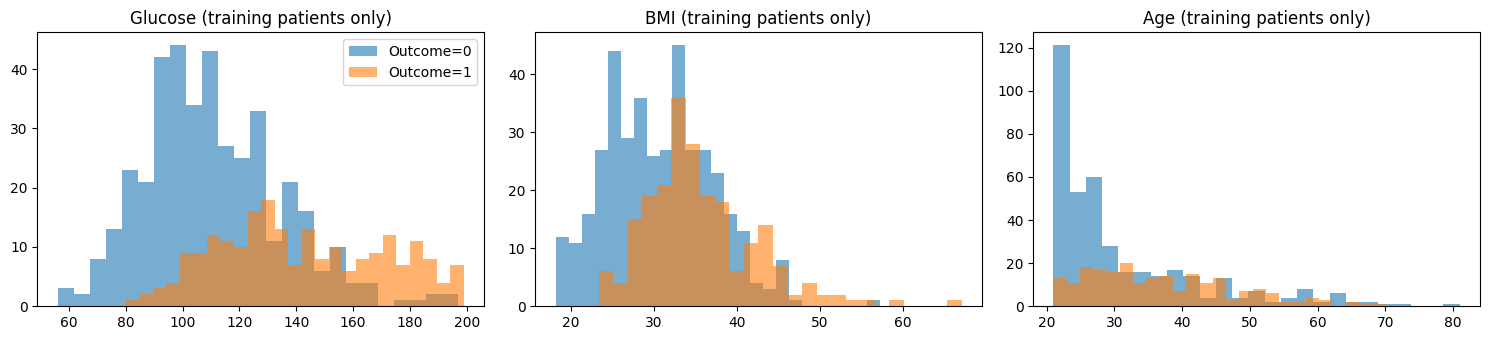

In [18]:
# แบ่งข้อมูล: ผู้ป่วยชุดทดสอบ (ผลลัพธ์ถูกซ่อนบนตารางอันดับ) และผู้ป่วยชุดข้อมูลฝึก (ใช้ปรับกฎ)
from sklearn.metrics import balanced_accuracy_score, recall_score

test_ids = pd.read_csv(lab_data("pima/test_ids.csv"))["id"]
train = df.drop(index=test_ids)                            # ผู้ป่วย 614 ราย - ใช้ปรับกฎจากชุดนี้เท่านั้น
test  = df.loc[test_ids].drop(columns=["Outcome"])         # ผู้ป่วยชุดทดสอบ 154 ราย (ผลลัพธ์ถูกซ่อน)
print(f"ชุดข้อมูลฝึก: {len(train)} ราย | ชุดทดสอบ: {len(test)} ราย")

def evaluate(rule, data=train):
    """แสดงความไว ความจำเพาะ และ balanced accuracy ของกฎ โดยคำนวณจากผู้ป่วยชุดข้อมูลฝึก"""
    pred = data.apply(rule, axis=1)
    sens = recall_score(data["Outcome"], pred, pos_label=1)
    spec = recall_score(data["Outcome"], pred, pos_label=0)
    bacc = balanced_accuracy_score(data["Outcome"], pred)
    print(f"ชุดข้อมูลฝึก: sensitivity={sens:.3f}  specificity={spec:.3f}  balanced accuracy={bacc:.3f}")

# ฮิสโทแกรมของผู้ป่วยชุดข้อมูลฝึกเท่านั้น
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ["Glucose", "BMI", "Age"]):
    for outcome, grp in train.groupby("Outcome"):
        ax.hist(grp[col], alpha=0.6, bins=25, label=f"Outcome={outcome}")
    ax.set_title(f"{col} (training patients only)")
axes[0].legend()
plt.tight_layout()
plt.show()

In [19]:
# 🏆 กฎพื้นฐาน (baseline): คัดกรองผู้ที่มีภาวะความทนต่อกลูโคสบกพร่องขึ้นไป (ระดับน้ำตาล OGTT ที่ 2 ชั่วโมง >= 140 mg/dL)
def screen(row):
    """คืนค่า 1 หากทำนายว่าเป็นโรคเบาหวาน มิฉะนั้นคืนค่า 0"""
    return int(row["Glucose"] >= 140)

evaluate(screen)                                           # คะแนนจากผู้ป่วยชุดข้อมูลฝึก

def make_submission(rule, path="lab01_submission.csv"):
    """ใช้กฎกับผู้ป่วยชุดทดสอบ 154 ราย บันทึกไฟล์ผลการทำนาย และส่งไปยังตารางอันดับ (หากระบุ NAME/JOIN_CODE แล้ว)"""
    preds = test.apply(rule, axis=1)
    sub = pd.DataFrame({"id": test_ids.values, "prediction": preds.values})
    sub.to_csv(path, index=False)
    print(f"บันทึกไฟล์ {path} เรียบร้อย:", sub["prediction"].value_counts().to_dict())
    if NAME and JOIN_CODE:
        submit_to_leaderboard(path)
    else:
        print("ยังไม่ได้ส่งผล - โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่า (และรันเซลล์นั้นใหม่) เพื่อส่งผล")

make_submission(screen)

ชุดข้อมูลฝึก: sensitivity=0.491  specificity=0.879  balanced accuracy=0.685
บันทึกไฟล์ lab01_submission.csv เรียบร้อย: {0: 112, 1: 42}
ยังไม่ได้ส่งผล - โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่า (และรันเซลล์นั้นใหม่) เพื่อส่งผล


💡 **คำอธิบายผลลัพธ์** กฎพื้นฐานคัดกรองผู้ป่วยทุกรายที่มีระดับน้ำตาลที่ 2 ชั่วโมง ≥ 140 mg/dL ผลที่แสดงคือความไวและความจำเพาะจากผู้ป่วยชุดข้อมูลฝึก 614 ราย คะแนนบนตารางอันดับจากผู้ป่วย 154 รายที่ซ่อนไว้ควรใกล้เคียงกัน แต่ไม่จำเป็นต้องเท่ากัน

### แนวทางการปรับปรุงให้ดีกว่า baseline
- ทดลองเกณฑ์ตัดสิน `Glucose` ค่าอื่น และสังเกตการแลกเปลี่ยน (trade-off) ระหว่างความไวกับความจำเพาะ การตรวจ *คัดกรอง* มักให้ความสำคัญกับความไว (≥ 200 mg/dL คือเกณฑ์ *วินิจฉัย* — โปรดตรวจสอบว่าเกณฑ์นี้ให้ความไวเท่าใดในชุดข้อมูลนี้ คำใบ้: พิจารณาค่าสูงสุดของ `Glucose` ในรายงานสรุปข้อมูล)
- ใช้หลายเงื่อนไขร่วมกัน เช่น `(Glucose >= 160) or (Glucose >= 120 and BMI >= 30)` หรือเพิ่มตัวแปร `Age`
- เลือกเกณฑ์ตัดสินจากฮิสโทแกรมของชุดข้อมูลฝึก หรือจาก `train.groupby("Outcome").median(numeric_only=True)` ห้ามใช้ข้อมูลผู้ป่วยชุดทดสอบ
- เขียน loop เพื่อทดลองเกณฑ์ตัดสินหลายค่า เรียก `evaluate` สำหรับแต่ละค่า แล้วเลือกค่าที่ดีที่สุด *จากชุดข้อมูลฝึก*

In [31]:
import random
from sklearn.metrics import balanced_accuracy_score, recall_score

# 1. เขียน loop แบบ Random Search ค้นหากฎ (ลดตัวแปร เน้นตัวแปรหลัก)
best_bacc = 0
best_sens = 0
best_params = (0, 0, 0, 0, 0)

print("กำลังสุ่มค้นหากฎ (ลดตัวแปร เน้น Glucose, BMI, Age) 100,000 รูปแบบ...")
for _ in range(100000):
    # สุ่มเฉพาะตัวแปรที่มีความสำคัญสูง
    g1 = random.randint(110, 180)
    g2 = random.randint(80, 140)
    g3 = random.randint(80, 140)
    bmi = random.randint(22, 45)
    age = random.randint(25, 55)

    # กฎที่เรียบง่ายขึ้น
    pred = (
        (train["Glucose"] >= g1) |
        ((train["Glucose"] >= g2) & (train["BMI"] >= bmi)) |
        ((train["Glucose"] >= g3) & (train["Age"] >= age))
    ).astype(int)

    bacc = balanced_accuracy_score(train["Outcome"], pred)
    sens = recall_score(train["Outcome"], pred)

    # พิจารณา Balanced Acc โดยมีเงื่อนไข Sensitivity >= 0.8
    if bacc > best_bacc and sens >= 0.8:
        best_bacc = bacc
        best_sens = sens
        best_params = (g1, g2, g3, bmi, age)

g1, g2, g3, bmi, age = best_params
if best_bacc > 0:
    print(f"💡 พบกฎที่ดีที่สุด (Balanced Acc = {best_bacc:.4f}, Sensitivity = {best_sens:.4f}):")
    print(f"   1. Glucose >= {g1} หรือ")
    print(f"   2. Glucose >= {g2} ร่วมกับ BMI >= {bmi} หรือ")
    print(f"   3. Glucose >= {g3} ร่วมกับ Age >= {age}")
    print("-" * 50)
else:
    print("ไม่พบกฎที่เข้าเงื่อนไข Sensitivity >= 0.8")

# 2. นำเกณฑ์ที่ได้มาสร้างกฎหลัก
def my_screen(row):
    if row["Glucose"] >= g1:
        return 1
    elif row["Glucose"] >= g2 and row["BMI"] >= bmi:
        return 1
    elif row["Glucose"] >= g3 and row["Age"] >= age:
        return 1
    return 0

evaluate(my_screen)                                        # คะแนนจากชุดข้อมูลฝึก
make_submission(my_screen)                                 # ส่งผลไปยัง Leaderboard


กำลังสุ่มค้นหากฎ (ลดตัวแปร เน้น Glucose, BMI, Age) 100,000 รูปแบบ...
💡 พบกฎที่ดีที่สุด (Balanced Acc = 0.7580, Sensitivity = 0.8165):
   1. Glucose >= 153 หรือ
   2. Glucose >= 129 ร่วมกับ BMI >= 31 หรือ
   3. Glucose >= 100 ร่วมกับ Age >= 31
--------------------------------------------------
ชุดข้อมูลฝึก: sensitivity=0.817  specificity=0.699  balanced accuracy=0.758
บันทึกไฟล์ lab01_submission.csv เรียบร้อย: {0: 80, 1: 74}
ยังไม่ได้ส่งผล - โปรดระบุ NAME และ JOIN_CODE ในเซลล์การตั้งค่า (และรันเซลล์นั้นใหม่) เพื่อส่งผล


In [26]:
# ตรวจสอบค่าสหสัมพันธ์ (Correlation) ของตัวแปรต่างๆ กับ Outcome เฉพาะในชุดข้อมูลฝึก (Training Set)
corr_with_outcome = train.corr(numeric_only=True)['Outcome'].sort_values(ascending=False)

print("ค่าสหสัมพันธ์ (Correlation) ของตัวแปรต่างๆ กับ Outcome (เรียงจากมากไปน้อย):")
display(corr_with_outcome)


ค่าสหสัมพันธ์ (Correlation) ของตัวแปรต่างๆ กับ Outcome (เรียงจากมากไปน้อย):


,Outcome
Outcome,1.000000
Glucose,0.499284
BMI,0.341126
Age,0.238085
SkinThickness,0.219928
Pregnancies,0.206151
DiabetesPedigreeFunction,0.193410
Insulin,0.185550
BloodPressure,0.175702


## ชิ้นงานที่ต้องส่ง (งานเดี่ยว)

ให้ส่งโน้ตบุ๊กนี้ซึ่งรันครบทุกเซลล์ตามลำดับจากบนลงล่าง พร้อมคำตอบในเซลล์ ✍️ **คำตอบ** ทุกเซลล์ (A1–A3 และ B1–B4 โดย B4 เป็นคำตอบหลัก 3 ประโยค) ตามช่องทางที่ระบุในแนวทางของรายวิชา

ผู้เรียนที่เข้าร่วมโจทย์ท้าทายบนตารางอันดับ 🏆 สามารถระบุชื่อบนตารางอันดับและคะแนนสูงสุดไว้ในส่วนนี้ (ไม่บังคับ และไม่มีผลต่อการประเมิน)

✍️ **ชื่อบนตารางอันดับ / คะแนน (ไม่บังคับ):**

## แหล่งศึกษาเพิ่มเติม
- [Diabetes 130-US Hospitals (readmission) dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) — จะใช้อีกครั้งในปฏิบัติการถัดไป
- `pip install ydata-profiling` สำหรับสร้างรายงานสรุปข้อมูลโดยอัตโนมัติ